Анализ частоты действий
Всего записей о действиях: 2539

Частота каждого действия (количество раз, когда оно было обнаружено):
  - playing saxophone: 358
  - doing aerobics: 308
  - throwing ball: 157
  - presenting weather forecast: 157
  - playing clarinet: 140
  - playing trumpet: 140
  - playing recorder: 135
  - swinging legs: 93
  - playing cello: 88
  - tying bow tie: 68
  - checking tires: 66
  - playing trombone: 66
  - trimming or shaving beard: 66
  - shooting basketball: 48
  - pull ups: 47
  - exercising with an exercise ball: 41
  - catching or throwing softball: 39
  - dribbling basketball: 31
  - bench pressing: 28
  - sign language interpreting: 27
  - playing bagpipes: 26
  - zumba: 24
  - playing ukulele: 22
  - playing badminton: 22
  - arm wrestling: 21
  - playing volleyball: 21
  - situp: 12
  - massaging back: 12
  - hurling (sport): 11
  - juggling soccer ball: 11
  - jogging: 9
  - riding unicycle: 9
  - capoeira: 9
  - tasting beer: 8
  - high kick: 8
  - pla

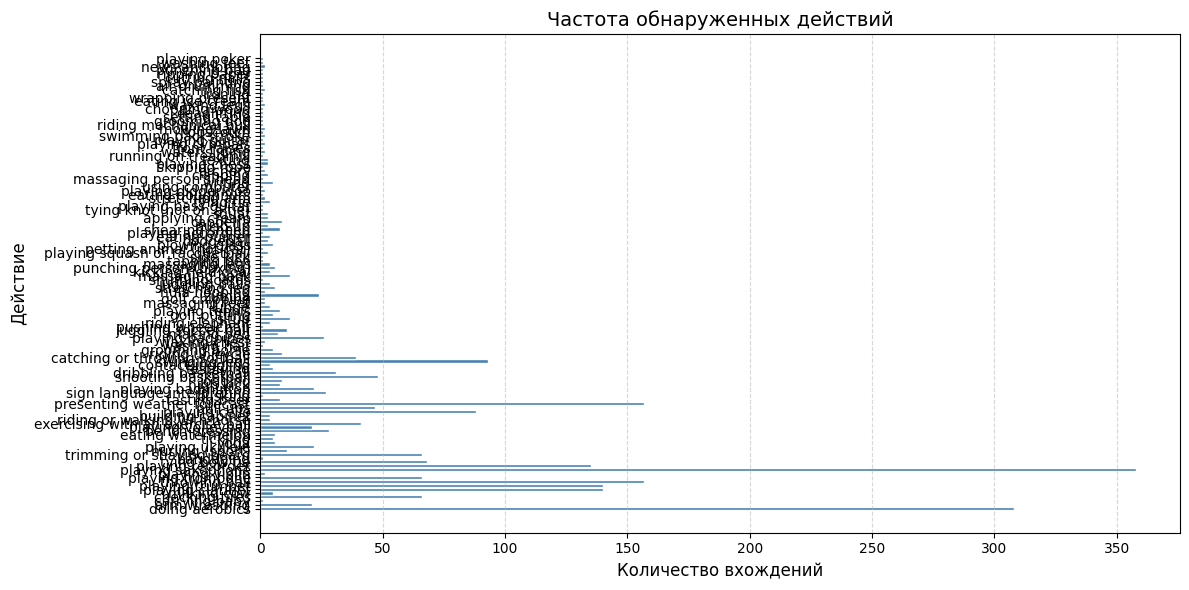


Топ-10 самых частых действий
  playing saxophone: 358 обнаружений, 358 непрерывных блоков
  doing aerobics: 308 обнаружений, 308 непрерывных блоков
  throwing ball: 157 обнаружений, 157 непрерывных блоков
  presenting weather forecast: 157 обнаружений, 157 непрерывных блоков
  playing clarinet: 140 обнаружений, 140 непрерывных блоков
  playing trumpet: 140 обнаружений, 140 непрерывных блоков
  playing recorder: 135 обнаружений, 135 непрерывных блоков
  swinging legs: 93 обнаружений, 93 непрерывных блоков
  playing cello: 88 обнаружений, 88 непрерывных блоков
  tying bow tie: 68 обнаружений, 68 непрерывных блоков


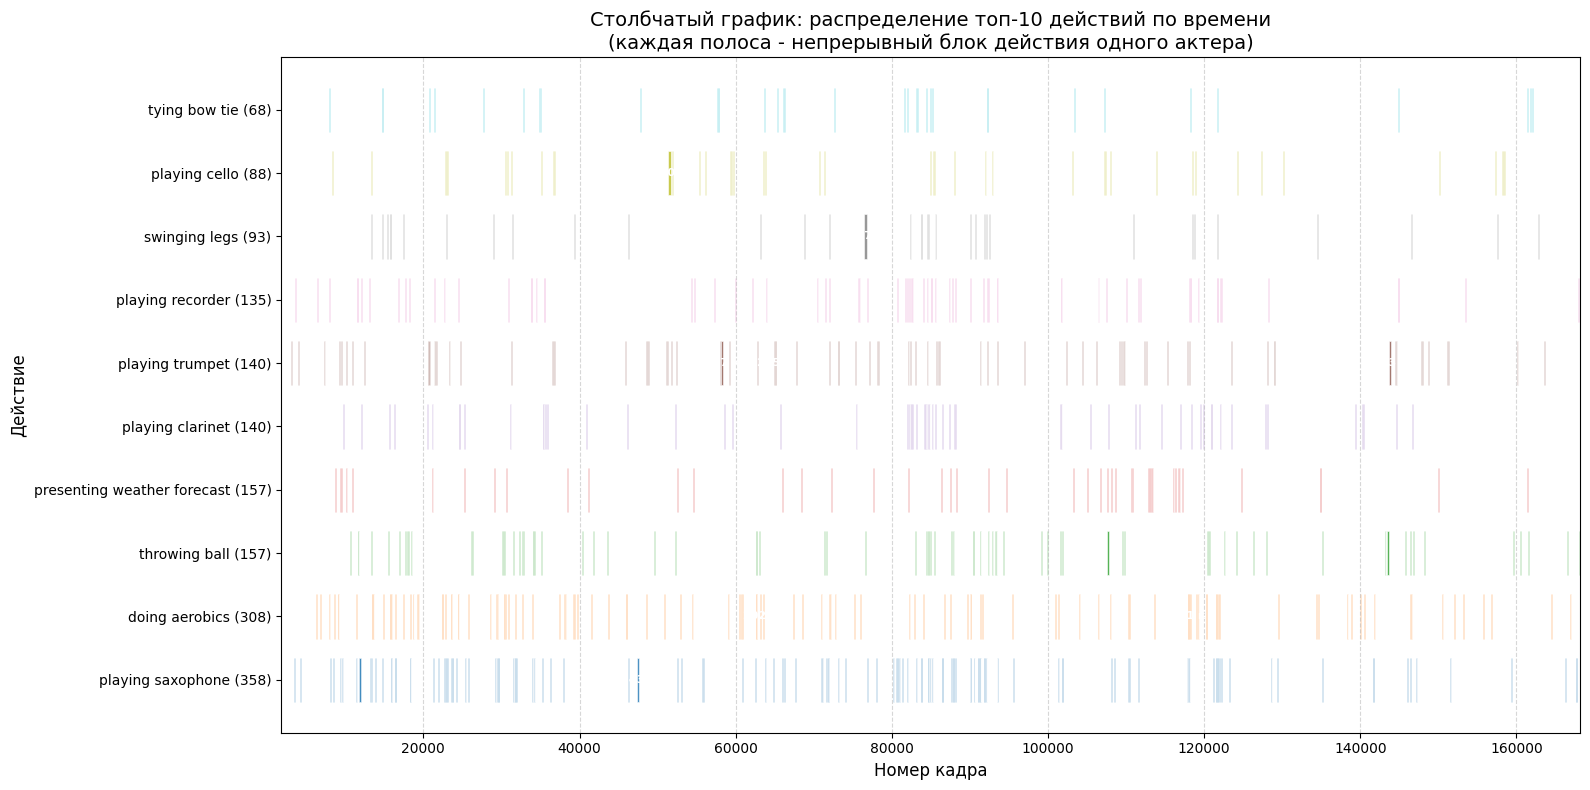

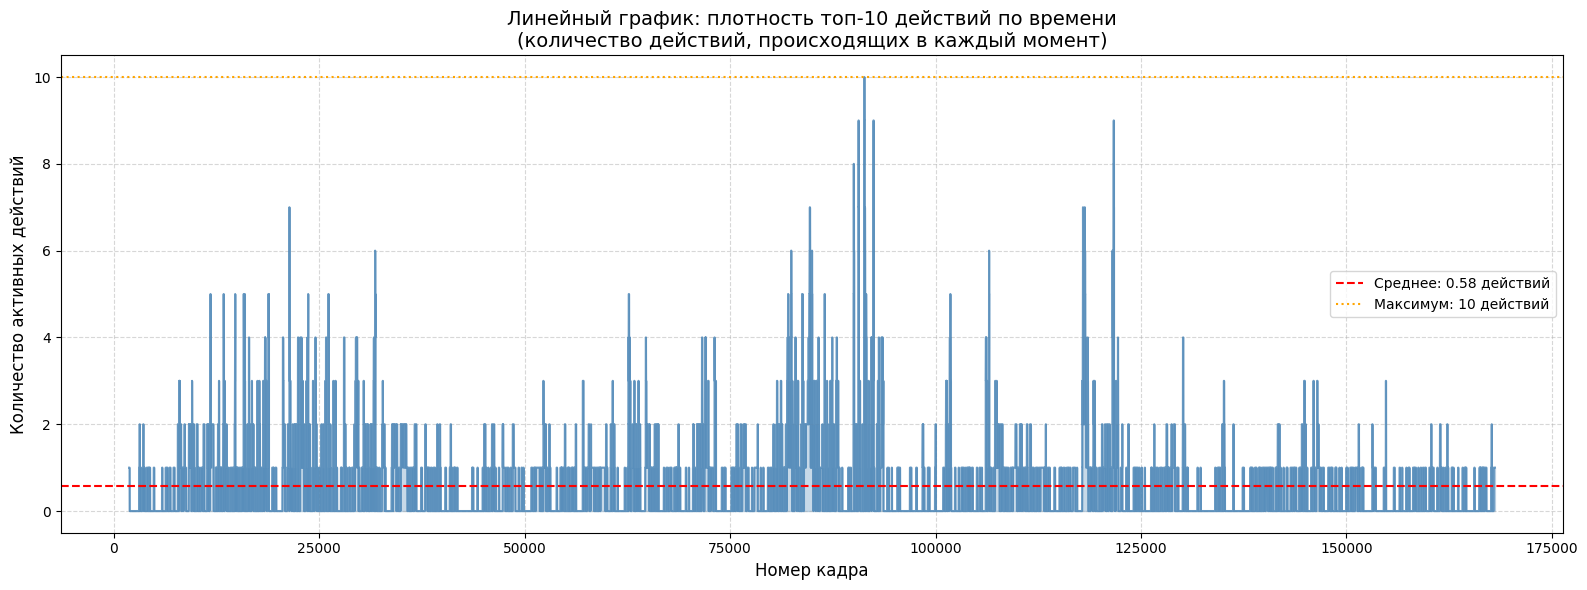

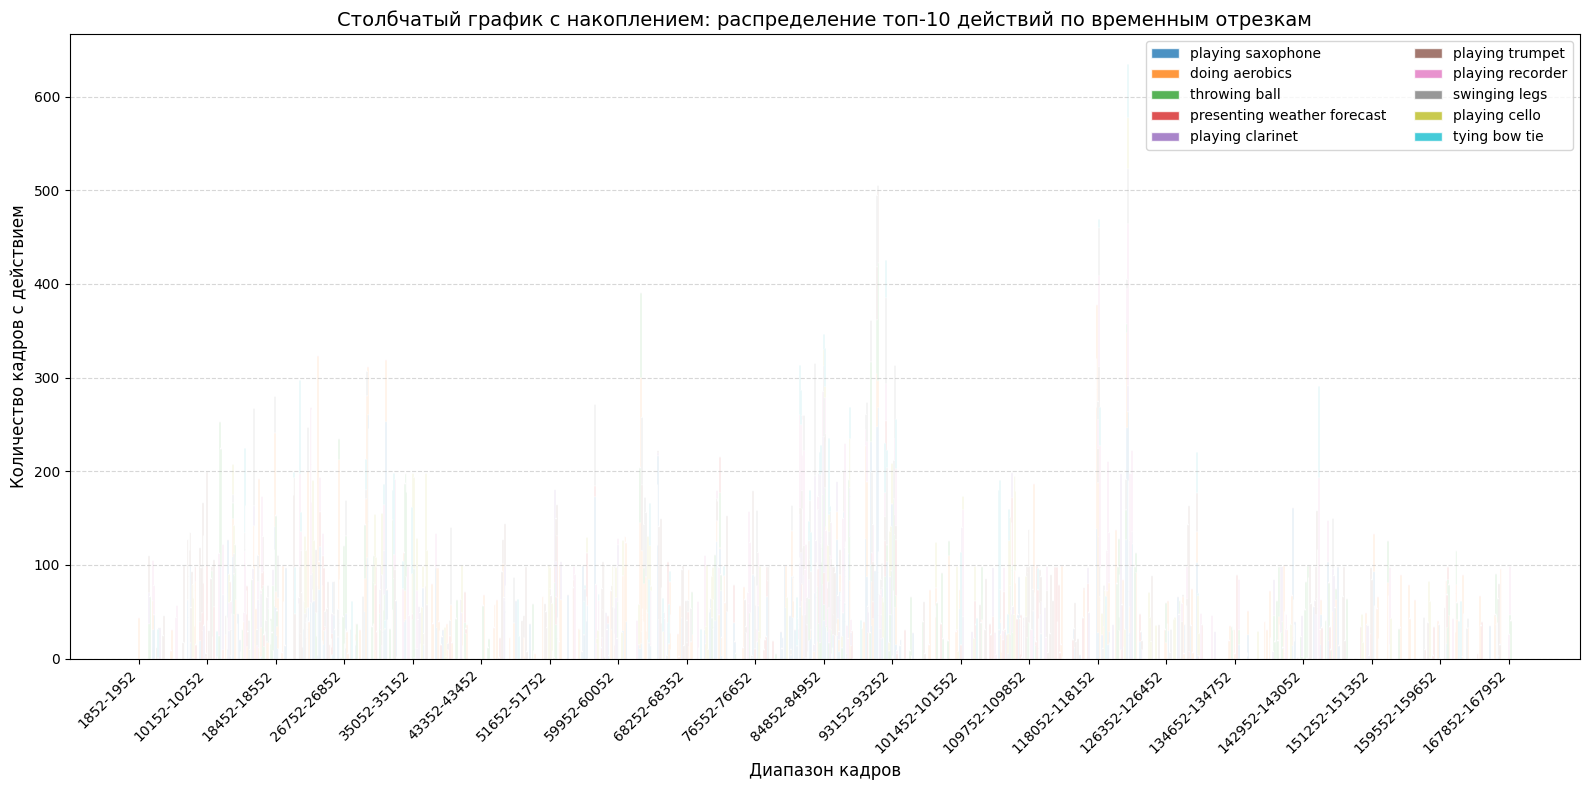


Анализ количества актеров в кадре
Всего кадров с обнаруженными позами: 146906
Среднее количество актеров в кадре: 2.25
Максимальное количество актеров в кадре: 25
Минимальное количество актеров в кадре: 1


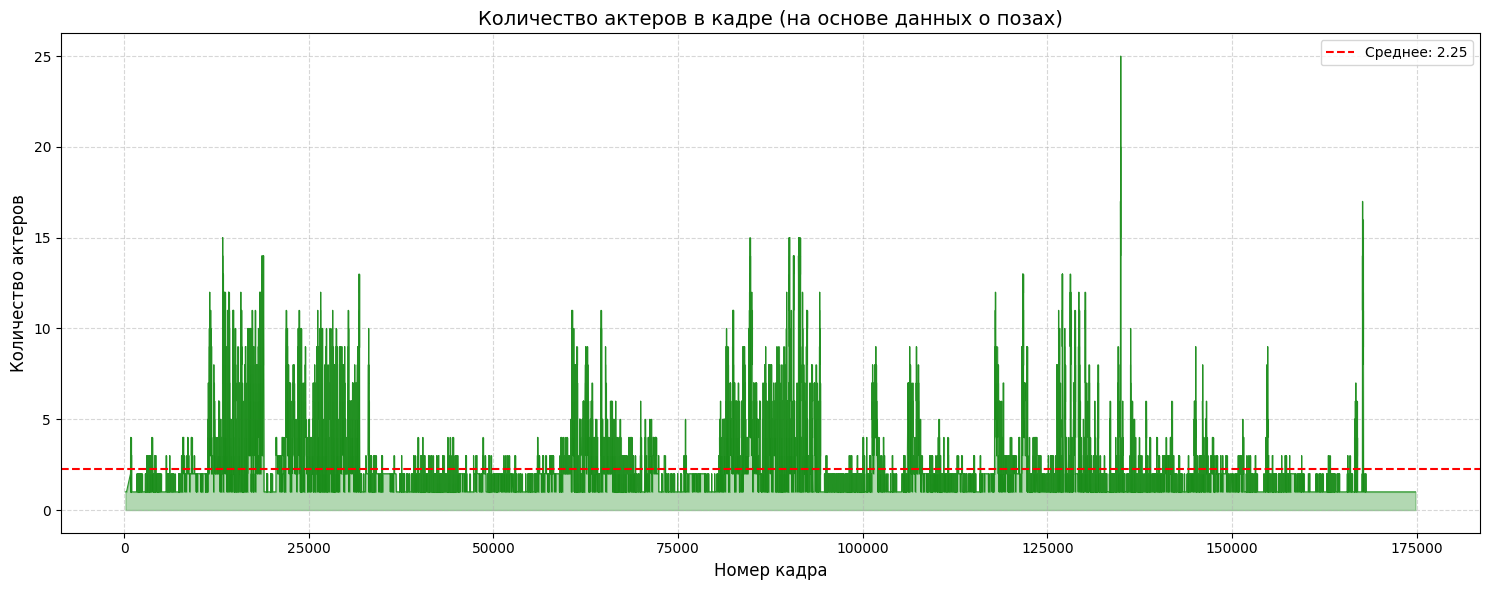

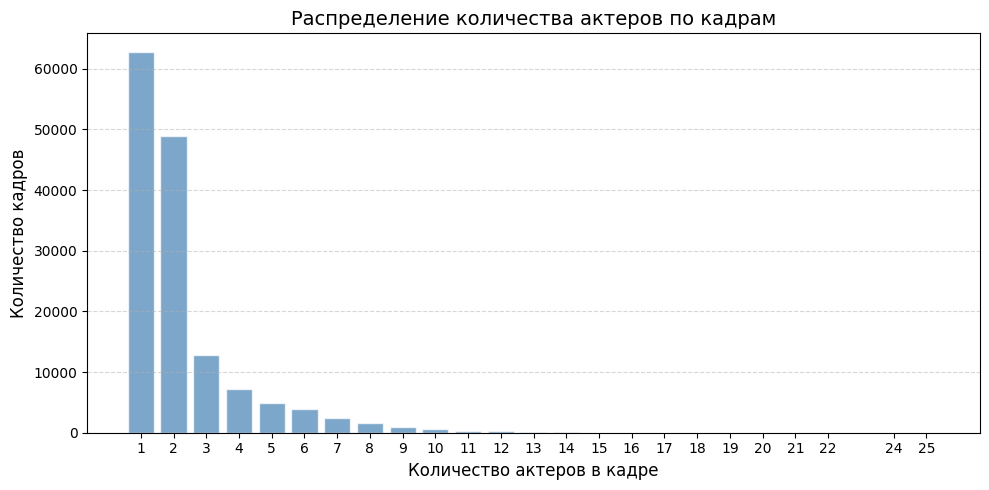

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter

# Загрузка данных из файла
try:
    with open('results.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
except FileNotFoundError:
    print("Ошибка: Файл results.json не найден.")
    exit()

# 1. Подготовка данных 

# Создаем словарь: frame_idx -> set(person_ids) из раздела "raw_poses"
poses_by_frame = defaultdict(set)
for pose in data['raw_poses']:
    if 'frame_idx' in pose and 'person_id' in pose:
        poses_by_frame[pose['frame_idx']].add(pose['person_id'])

# Создаем список действий из раздела "pose_actions"
actions_data = []
for action in data['pose_actions']:
    if 'frame_idx' in action and 'person_id' in action and action.get('action', {}).get('action_name'):
        actions_data.append((
            action['frame_idx'],
            action['person_id'],
            action['action']['action_name']
        ))

# Сортируем действия по кадру
actions_data.sort(key=lambda x: x[0])

# 2. Анализ частоты действий 
action_counter = Counter([action_name for _, _, action_name in actions_data])

print("Анализ частоты действий")
print(f"Всего записей о действиях: {len(actions_data)}")
print("\nЧастота каждого действия (количество раз, когда оно было обнаружено):")
for action, count in action_counter.most_common():
    print(f"  - {action}: {count}")

# Построение графика частоты действий
if action_counter:
    plt.figure(figsize=(12, 6))
    actions = list(action_counter.keys())
    counts = list(action_counter.values())
    plt.barh(actions, counts, color='steelblue', edgecolor='white')
    plt.xlabel('Количество вхождений', fontsize=12)
    plt.ylabel('Действие', fontsize=12)
    plt.title('Частота обнаруженных действий', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных о действиях для построения графика частоты.")


# 3. Определение временных интервалов для каждого действия 
# Учитываем, что действие длится с кадра обнаружения до следующей записи 
# с тем же ID актера или до пропадания ID из кадра

# Группируем действия по person_id
actions_by_person = defaultdict(list)
for frame, person, action_name in actions_data:
    actions_by_person[person].append((frame, action_name))

# Словарь для хранения интервалов: action_name -> [(start_frame, end_frame), ...]
action_intervals = defaultdict(list)

for person_id, person_actions in actions_by_person.items():
    # Сортируем действия этого актера по кадру
    person_actions.sort(key=lambda x: x[0])
    
    # Получаем все кадры, где этот актер присутствует в позах
    person_pose_frames = sorted([frame for frame, persons in poses_by_frame.items() if person_id in persons])
    if not person_pose_frames:
        continue
    
    # Обрабатываем каждое действие актера
    for i, (start_frame, action_name) in enumerate(person_actions):
        # Определяем кадр, на котором действие заканчивается
        end_frame = person_pose_frames[-1]  # по умолчанию до конца присутствия
        
        # 1. Если это не последнее действие актера, конец - кадр перед началом следующего действия
        if i + 1 < len(person_actions):
            next_action_frame = person_actions[i+1][0]
            # Ищем последний кадр, где актер присутствует, но который меньше начала следующего действия
            possible_end_frames = [f for f in person_pose_frames if f < next_action_frame]
            if possible_end_frames:
                end_frame = max(possible_end_frames)
            else:
                end_frame = start_frame
        else:
            # Для последнего действия - конец, когда актер перестает обнаруживаться
            end_frame = max(person_pose_frames)
        
        # Сохраняем интервал
        if end_frame >= start_frame:
            action_intervals[action_name].append((start_frame, end_frame, person_id))

# 4. Выбор топ-10 самых частых действий
top_actions = [action for action, _ in action_counter.most_common(10)]

print(f"\nТоп-10 самых частых действий")
for action in top_actions:
    total_blocks = len(action_intervals.get(action, []))
    print(f"  {action}: {action_counter[action]} обнаружений, {total_blocks} непрерывных блоков")

# Создаем цветовую карту для действий
colors = plt.cm.tab10(np.linspace(0, 1, len(top_actions)))
action_colors = {action: colors[i] for i, action in enumerate(top_actions)}

# 5. СТОЛБЧАТЫЙ ГРАФИК
# Каждый столбец - непрерывный блок действия, объединяем всех актеров

fig, ax = plt.subplots(figsize=(16, 8))

# Сортируем действия по частоте для отображения
sorted_actions = sorted(top_actions, key=lambda x: action_counter[x], reverse=True)

y_positions = {}
for idx, action_name in enumerate(sorted_actions):
    y_pos = idx + 1
    y_positions[action_name] = y_pos
    
    intervals = action_intervals.get(action_name, [])
    for start, end, person_id in intervals:
        width = end - start
        ax.barh(y_pos, width, left=start, height=0.7, 
               color=action_colors[action_name], alpha=0.8, edgecolor='white', linewidth=0.5)
        
        # Добавляем аннотацию для длинных блоков
        if width > 200:
            ax.text(start + width/2, y_pos, f'{width} к', 
                   ha='center', va='center', fontsize=8, color='white', weight='bold')

ax.set_yticks(range(1, len(sorted_actions) + 1))
ax.set_yticklabels([f"{action} ({action_counter[action]})" for action in sorted_actions])
ax.set_xlabel('Номер кадра', fontsize=12)
ax.set_ylabel('Действие', fontsize=12)
ax.set_title('Столбчатый график: распределение топ-10 действий по времени\n(каждая полоса - непрерывный блок действия одного актера)', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Находим границы кадров
all_frames = []
for intervals in action_intervals.values():
    for start, end, _ in intervals:
        all_frames.extend([start, end])
if all_frames:
    ax.set_xlim(min(all_frames) - 50, max(all_frames) + 50)

plt.tight_layout()
plt.show()


# 6. ЛИНЕЙНЫЙ ГРАФИК
# Показывает, сколько действий происходит в каждый момент времени

if all_frames:
    time_min = min(all_frames)
    time_max = max(all_frames)
    
    # Создаем массив для подсчета активных действий в каждом кадре
    action_density = np.zeros(time_max - time_min + 1)
    
    # Для каждого действия из топ-10 добавляем его вклад в плотность
    for action_name in top_actions:
        intervals = action_intervals.get(action_name, [])
        for start, end, _ in intervals:
            start_idx = start - time_min
            end_idx = end - time_min
            action_density[start_idx:end_idx + 1] += 1
    
    time_axis = np.arange(time_min, time_max + 1)
    
    # Линейный график плотности
    fig, ax = plt.subplots(figsize=(16, 6))
    
    ax.plot(time_axis, action_density, linewidth=1.5, color='steelblue', alpha=0.8)
    ax.fill_between(time_axis, 0, action_density, alpha=0.3, color='steelblue')
    
    # Добавляем горизонтальные линии для статистики
    avg_density = np.mean(action_density)
    max_density = np.max(action_density)
    ax.axhline(y=avg_density, color='red', linestyle='--', linewidth=1.5, 
               label=f'Среднее: {avg_density:.2f} действий')
    ax.axhline(y=max_density, color='orange', linestyle=':', linewidth=1.5, 
               label=f'Максимум: {int(max_density)} действий')
    
    ax.set_xlabel('Номер кадра', fontsize=12)
    ax.set_ylabel('Количество активных действий', fontsize=12)
    ax.set_title('Линейный график: плотность топ-10 действий по времени\n(количество действий, происходящих в каждый момент)', fontsize=14)
    ax.legend()
    ax.grid(axis='both', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


#7. СТОЛБЧАТЫЙ ГРАФИК С НАКОПЛЕНИЕМ
# Показывает, какие действия доминируют в разные периоды времени

# Разбиваем временную шкалу на сегменты (по 100 кадров)
segment_size = 100
if all_frames:
    num_segments = (max(all_frames) - min(all_frames)) // segment_size + 2
    segments = []
    segment_actions = defaultdict(lambda: defaultdict(int))
    
    for seg_idx in range(num_segments):
        seg_start = min(all_frames) + seg_idx * segment_size
        seg_end = seg_start + segment_size
        segments.append((seg_start, seg_end))
        
        for action_name in top_actions:
            intervals = action_intervals.get(action_name, [])
            total_frames = 0
            for start, end, _ in intervals:
                overlap_start = max(start, seg_start)
                overlap_end = min(end, seg_end)
                if overlap_end > overlap_start:
                    total_frames += (overlap_end - overlap_start)
            segment_actions[seg_idx][action_name] = total_frames
    
    # Строим stacked bar chart
    fig, ax = plt.subplots(figsize=(16, 8))
    
    bottom = np.zeros(num_segments)
    x_positions = np.arange(num_segments)
    x_labels = [f"{s[0]}-{s[1]}" for s in segments]
    
    for action_name in sorted_actions:
        values = [segment_actions[seg_idx][action_name] for seg_idx in range(num_segments)]
        ax.bar(x_positions, values, bottom=bottom, label=action_name, 
               color=action_colors[action_name], alpha=0.8, edgecolor='white', width=0.8)
        bottom += values
    
    ax.set_xlabel('Диапазон кадров', fontsize=12)
    ax.set_ylabel('Количество кадров с действием', fontsize=12)
    ax.set_title('Столбчатый график с накоплением: распределение топ-10 действий по временным отрезкам', fontsize=14)
    
    # Уменьшаем количество меток на оси X для читаемости
    step = max(1, num_segments // 20)
    ax.set_xticks(x_positions[::step])
    ax.set_xticklabels(x_labels[::step], rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=10, ncol=2)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


# 8. Анализ количества актеров в кадре
frames_with_poses = sorted(poses_by_frame.keys())
if frames_with_poses:
    actors_count_by_frame = {frame: len(poses_by_frame[frame]) for frame in frames_with_poses}
    
    # Выводим статистику
    print("\nАнализ количества актеров в кадре")
    print(f"Всего кадров с обнаруженными позами: {len(actors_count_by_frame)}")
    avg_actors = sum(actors_count_by_frame.values()) / len(actors_count_by_frame)
    print(f"Среднее количество актеров в кадре: {avg_actors:.2f}")
    print(f"Максимальное количество актеров в кадре: {max(actors_count_by_frame.values())}")
    print(f"Минимальное количество актеров в кадре: {min(actors_count_by_frame.values())}")
    
    # Визуализация количества актеров в кадре по времени
    plt.figure(figsize=(15, 6))
    frames = list(actors_count_by_frame.keys())
    counts = list(actors_count_by_frame.values())
    
    plt.plot(frames, counts, linewidth=0.8, color='green', alpha=0.8)
    plt.fill_between(frames, counts, alpha=0.3, color='green')
    plt.axhline(y=avg_actors, color='red', linestyle='--', linewidth=1.5, 
                label=f'Среднее: {avg_actors:.2f}')
    
    plt.xlabel('Номер кадра', fontsize=12)
    plt.ylabel('Количество актеров', fontsize=12)
    plt.title('Количество актеров в кадре (на основе данных о позах)', fontsize=14)
    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Гистограмма распределения количества актеров
    plt.figure(figsize=(10, 5))
    unique_counts = sorted(set(counts))
    count_distribution = [list(counts).count(c) for c in unique_counts]
    
    plt.bar(unique_counts, count_distribution, color='steelblue', edgecolor='white', alpha=0.7)
    plt.xlabel('Количество актеров в кадре', fontsize=12)
    plt.ylabel('Количество кадров', fontsize=12)
    plt.title('Распределение количества актеров по кадрам', fontsize=14)
    plt.xticks(unique_counts)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
else:
    print("Нет данных о позах для анализа количества актеров в кадре.")

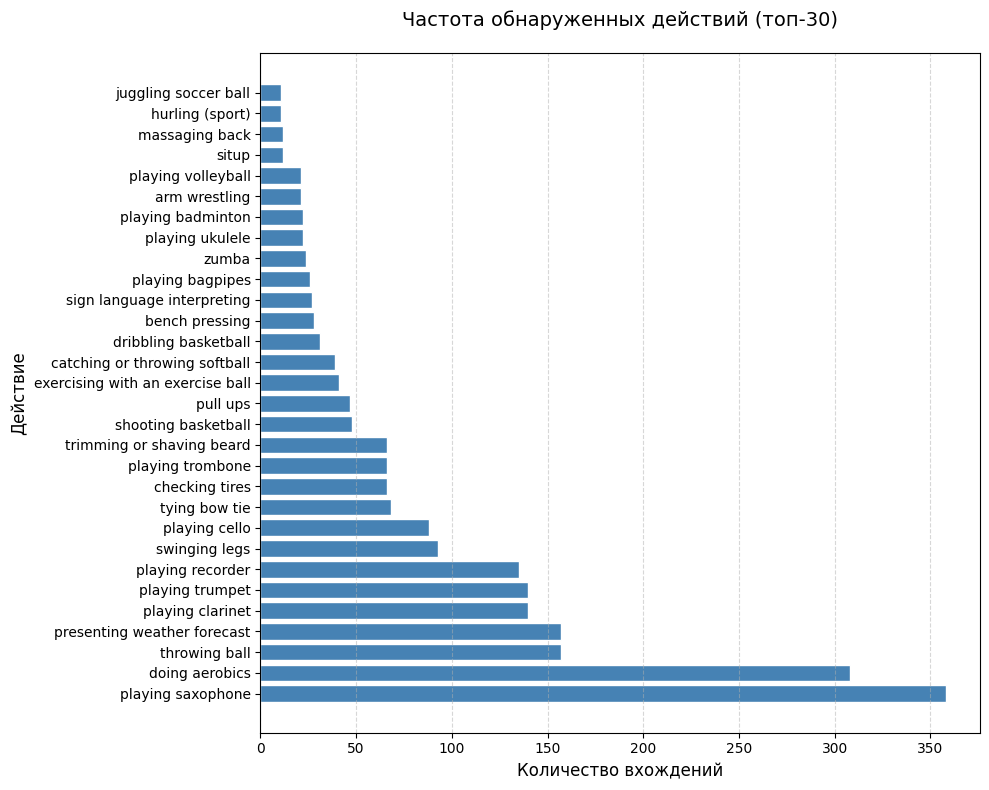

Всего действий: 117. Показаны топ-30


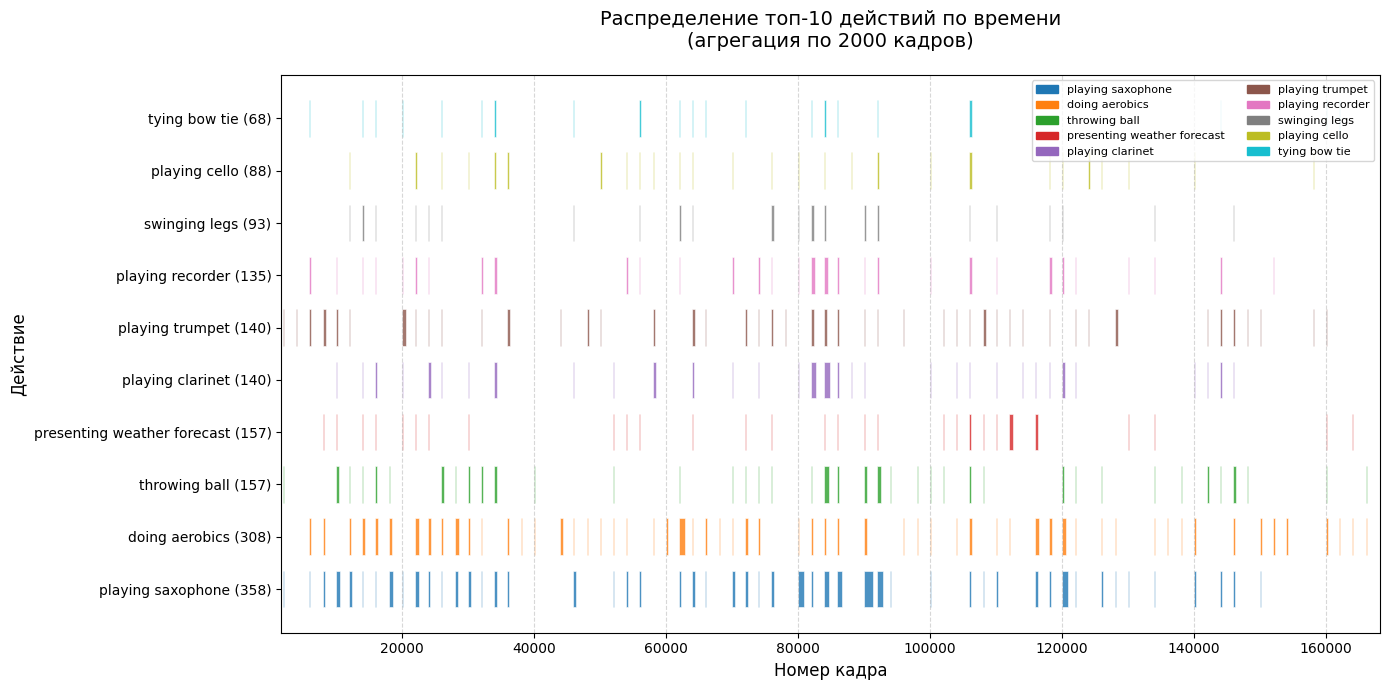

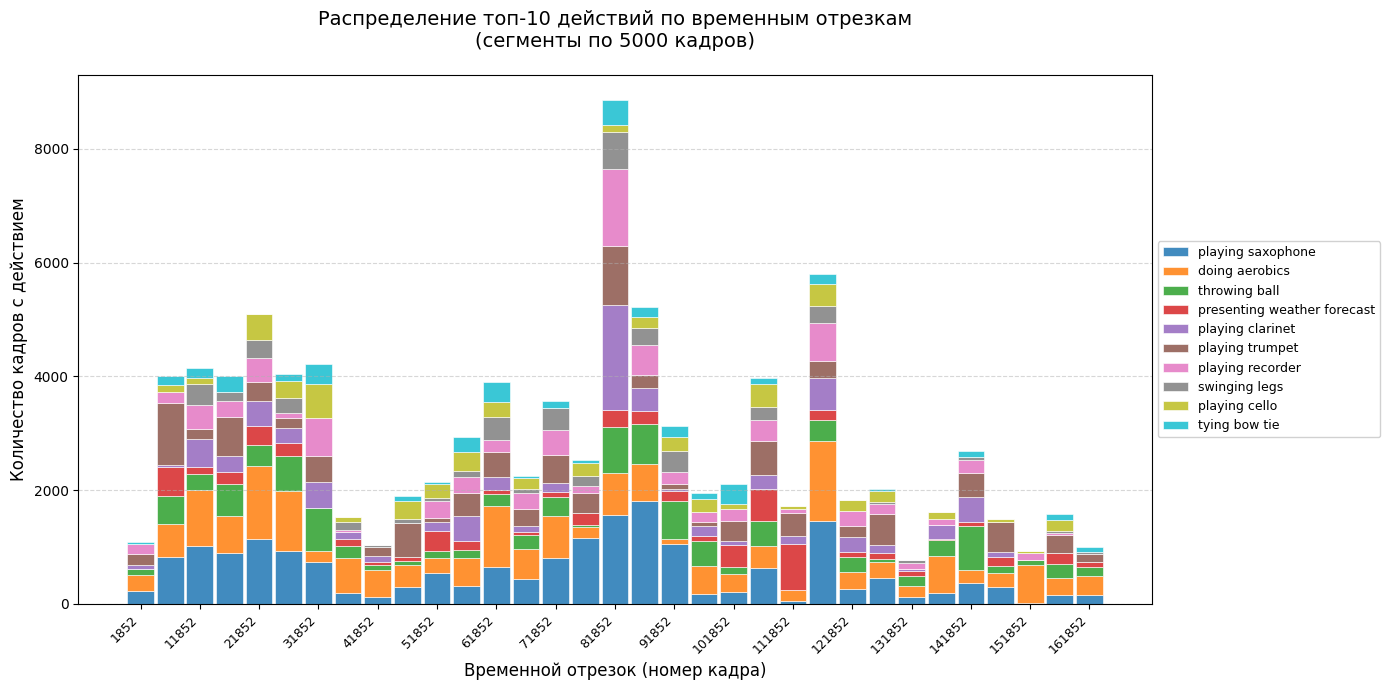

Создано 33 временных сегментов по 5000 кадров


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ГРАФИК 1: Частота действий (топ-30) 
if action_counter:
    top_n = 30  # Показываем только топ-30
    most_common = action_counter.most_common(top_n)
    
    plt.figure(figsize=(10, 8))
    actions = [action for action, _ in most_common]
    counts = [count for _, count in most_common]
    
    plt.barh(actions, counts, color='steelblue', edgecolor='white')
    plt.xlabel('Количество вхождений', fontsize=12)
    plt.ylabel('Действие', fontsize=12)
    plt.title(f'Частота обнаруженных действий (топ-{top_n})', fontsize=14, pad=20)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    if len(action_counter) > top_n:
        print(f"Всего действий: {len(action_counter)}. Показаны топ-{top_n}")


# ГРАФИК 2: Распределение по времени 
# Создаем цветовую карту для топ-10 действий
top_10_actions = [action for action, _ in action_counter.most_common(10)]
colors = plt.cm.tab10(np.linspace(0, 1, len(top_10_actions)))
action_colors = {action: colors[i] for i, action in enumerate(top_10_actions)}

if action_intervals and top_10_actions:
    # Собираем все кадры для определения диапазона
    all_frames = []
    for intervals in action_intervals.values():
        for start, end, _ in intervals:
            all_frames.extend([start, end])
    
    if all_frames:
        fig, ax = plt.subplots(figsize=(14, 7))
        
        # Сортируем действия по частоте
        sorted_actions = sorted(top_10_actions, key=lambda x: action_counter[x], reverse=True)
        
        # Агрегация: группируем интервалы по блокам для читаемости
        aggregation_window = 2000  # Размер окна агрегации (настройте под ваши данные)
        
        for idx, action_name in enumerate(sorted_actions):
            y_pos = idx + 1
            intervals = action_intervals.get(action_name, [])
            
            # Агрегируем интервалы
            aggregated_intervals = defaultdict(int)
            for start, end, person_id in intervals:
                # Округляем до ближайшего окна
                window_start = (start // aggregation_window) * aggregation_window
                aggregated_intervals[window_start] += (end - start)
            
            # Рисуем агрегированные интервалы
            for window_start, total_width in sorted(aggregated_intervals.items()):
                if total_width > 50:  # Показываем только значимые блоки
                    ax.barh(y_pos, total_width, left=window_start, height=0.7,
                           color=action_colors[action_name], alpha=0.8,
                           edgecolor='white', linewidth=0.5)
        
        ax.set_yticks(range(1, len(sorted_actions) + 1))
        ax.set_yticklabels([f"{action} ({action_counter[action]})" for action in sorted_actions], fontsize=10)
        ax.set_xlabel('Номер кадра', fontsize=12)
        ax.set_ylabel('Действие', fontsize=12)
        ax.set_title(f'Распределение топ-10 действий по времени\n(агрегация по {aggregation_window} кадров)', 
                    fontsize=14, pad=20)
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        
        # Устанавливаем границы
        ax.set_xlim(min(all_frames) - 100, max(all_frames) + 100)
        
        # Добавляем легенду
        legend_patches = [plt.Rectangle((0,0),1,1, color=action_colors[action]) 
                         for action in sorted_actions]
        ax.legend(legend_patches, sorted_actions, loc='upper right', 
                 bbox_to_anchor=(1.0, 1.0), fontsize=8, ncol=2)
        
        plt.tight_layout()
        plt.show()


# ГРАФИК 3: Stacked bar chart 
if all_frames and top_10_actions:
    # Определяем размер сегмента на основе общего количества кадров
    time_range = max(all_frames) - min(all_frames)
    segment_size = 5000  # Начальный размер сегмента
    
    # Адаптируем размер сегмента чтобы получить разумное количество колонок
    num_segments = max(1, time_range // segment_size)
    max_segments = 40  # Максимум колонок на графике
    
    if num_segments > max_segments:
        segment_size = time_range // max_segments
        num_segments = max_segments
    
    # Создаем сегменты
    segments = []
    segment_actions = defaultdict(lambda: defaultdict(int))
    
    for seg_idx in range(num_segments):
        seg_start = min(all_frames) + seg_idx * segment_size
        seg_end = seg_start + segment_size
        segments.append((seg_start, seg_end))
        
        # Подсчитываем кадры для каждого действия в этом сегменте
        for action_name in top_10_actions:
            intervals = action_intervals.get(action_name, [])
            total_frames = 0
            for start, end, _ in intervals:
                overlap_start = max(start, seg_start)
                overlap_end = min(end, seg_end)
                if overlap_end > overlap_start:
                    total_frames += (overlap_end - overlap_start)
            segment_actions[seg_idx][action_name] = total_frames
    
    # Строим stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    bottom = np.zeros(num_segments)
    x_positions = np.arange(num_segments)
    
    # Сортируем действия по частоте
    sorted_actions = sorted(top_10_actions, key=lambda x: action_counter[x], reverse=True)
    
    # Рисуем столбцы для каждого действия
    for action_name in sorted_actions:
        values = [segment_actions[seg_idx][action_name] for seg_idx in range(num_segments)]
        ax.bar(x_positions, values, bottom=bottom, label=action_name,
               color=action_colors[action_name], alpha=0.85, 
               edgecolor='white', linewidth=0.5, width=0.9)
        bottom += values
    
    # Настраиваем оси
    ax.set_xlabel('Временной отрезок (номер кадра)', fontsize=12)
    ax.set_ylabel('Количество кадров с действием', fontsize=12)
    ax.set_title(f'Распределение топ-10 действий по временным отрезкам\n(сегменты по {segment_size} кадров)', 
                fontsize=14, pad=20)
    
    # Показываем только некоторые метки на оси X
    step = max(1, num_segments // 15)
    x_labels = [f"{segments[i][0]}" for i in range(num_segments)]
    ax.set_xticks(x_positions[::step])
    ax.set_xticklabels(x_labels[::step], rotation=45, ha='right', fontsize=9)
    
    # Добавляем легенду снаружи
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), 
             fontsize=9, ncol=1, framealpha=0.9)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Создано {num_segments} временных сегментов по {segment_size} кадров")